# RescueTwin AI - Modelado predictivo

Este notebook entrena modelos de clasificación para predecir el nivel de riesgo operativo de una zona de derrumbe a partir de sensores simulados del robot cuadrúpedo.

La variable objetivo es:

`nivel_riesgo`

Con tres posibles clases:

- Bajo
- Medio
- Alto

Se comparan dos modelos:

1. Árbol de Decisión
2. Random Forest

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("../data/processed/rescuetwin_dataset.csv")

print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (2000, 24)


,zona,temperatura,humedad,presion,luz,sonido_db,co2,particulas_pm25,gas_tipo,gas_ppm,...,senal_comunicacion,bateria,voltaje_bateria,temperatura_bateria,autonomia_estimada_min,visibilidad,persona_detectada,confianza_persona,nivel_riesgo,accion_recomendada
0,Punto crítico,23.742562,37.156921,951.246360,0.59255,54.215643,505.075257,136.682603,gas_desconocido,16.081237,...,51.8,36.395081,10.82,4,28.5,45.2,0,0.11,Alto,Cambiar ruta o detenerse
1,Punto crítico,22.381415,37.422549,900.000000,0.00000,70.790609,545.730161,168.990470,humo,447.921945,...,58.6,61.886486,12.10,24,45.9,28.5,0,0.05,Alto,Cambiar ruta o detenerse
2,Túnel estrecho,22.333412,19.738998,941.234135,0.00000,50.419725,2085.626242,20.303590,sin_gas,326.041341,...,33.5,51.792509,11.46,24,37.8,72.8,0,0.14,Alto,Cambiar ruta o detenerse
3,Túnel estrecho,21.993103,40.284164,938.066586,0.53330,18.377416,2098.968669,102.632636,amoniaco,368.769094,...,23.5,60.061447,11.91,4,47.4,54.9,0,0.12,Alto,Cambiar ruta o detenerse
4,Habitación bloqueada,24.145010,42.892223,944.360592,0.47405,34.733886,915.139906,49.429148,sin_gas,1.303732,...,35.1,33.434138,11.06,24,23.1,74.9,0,0.19,Medio,Avanzar con precaución


In [3]:
df.info()
df["nivel_riesgo"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   zona                    2000 non-null   object 
 1   temperatura             2000 non-null   float64
 2   humedad                 2000 non-null   float64
 3   presion                 2000 non-null   float64
 4   luz                     2000 non-null   float64
 5   sonido_db               2000 non-null   float64
 6   co2                     2000 non-null   float64
 7   particulas_pm25         2000 non-null   float64
 8   gas_tipo                2000 non-null   object 
 9   gas_ppm                 2000 non-null   float64
 10  vibracion               2000 non-null   float64
 11  inclinacion             2000 non-null   float64
 12  distancia_obstaculo     2000 non-null   float64
 13  velocidad_robot         2000 non-null   float64
 14  senal_comunicacion      2000 non-null   

nivel_riesgo
Alto     1035
Medio     837
Bajo      128
Name: count, dtype: int64

In [4]:
columnas_excluir = [
    "zona",
    "nivel_riesgo",
    "accion_recomendada"
]

X = df.drop(columns=columnas_excluir)
y = df["nivel_riesgo"]

print("Variables predictoras:")
print(X.columns.tolist())

print("\nVariable objetivo:")
print(y.name)

Variables predictoras:
['temperatura', 'humedad', 'presion', 'luz', 'sonido_db', 'co2', 'particulas_pm25', 'gas_tipo', 'gas_ppm', 'vibracion', 'inclinacion', 'distancia_obstaculo', 'velocidad_robot', 'senal_comunicacion', 'bateria', 'voltaje_bateria', 'temperatura_bateria', 'autonomia_estimada_min', 'visibilidad', 'persona_detectada', 'confianza_persona']

Variable objetivo:
nivel_riesgo


In [5]:
X = pd.get_dummies(X, columns=["gas_tipo"], drop_first=True)

X.head()

,temperatura,humedad,presion,luz,sonido_db,co2,particulas_pm25,gas_ppm,vibracion,inclinacion,...,temperatura_bateria,autonomia_estimada_min,visibilidad,persona_detectada,confianza_persona,gas_tipo_gas_desconocido,gas_tipo_humo,gas_tipo_metano,gas_tipo_monoxido_carbono,gas_tipo_sin_gas
0,23.742562,37.156921,951.246360,0.59255,54.215643,505.075257,136.682603,16.081237,1.31,19.3,...,4,28.5,45.2,0,0.11,True,False,False,False,False
1,22.381415,37.422549,900.000000,0.00000,70.790609,545.730161,168.990470,447.921945,1.63,0.1,...,24,45.9,28.5,0,0.05,False,True,False,False,False
2,22.333412,19.738998,941.234135,0.00000,50.419725,2085.626242,20.303590,326.041341,0.43,22.3,...,24,37.8,72.8,0,0.14,False,False,False,False,True
3,21.993103,40.284164,938.066586,0.53330,18.377416,2098.968669,102.632636,368.769094,0.93,26.2,...,4,47.4,54.9,0,0.12,False,False,False,False,False
4,24.145010,42.892223,944.360592,0.47405,34.733886,915.139906,49.429148,1.303732,2.33,8.7,...,24,23.1,74.9,0,0.19,False,False,False,False,True


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Tamaño X_train:", X_train.shape)
print("Tamaño X_test:", X_test.shape)

print("\nDistribución en entrenamiento:")
print(y_train.value_counts(normalize=True))

print("\nDistribución en prueba:")
print(y_test.value_counts(normalize=True))

Tamaño X_train: (1600, 25)
Tamaño X_test: (400, 25)

Distribución en entrenamiento:
nivel_riesgo
Alto     0.51750
Medio    0.41875
Bajo     0.06375
Name: proportion, dtype: float64

Distribución en prueba:
nivel_riesgo
Alto     0.5175
Medio    0.4175
Bajo     0.0650
Name: proportion, dtype: float64


In [7]:
modelo_arbol = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

modelo_arbol.fit(X_train, y_train)

y_pred_arbol = modelo_arbol.predict(X_test)

In [8]:
accuracy_arbol = accuracy_score(y_test, y_pred_arbol)

print("Accuracy Árbol de Decisión:", round(accuracy_arbol, 4))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_arbol))

Accuracy Árbol de Decisión: 0.765

Reporte de clasificación:
              precision    recall  f1-score   support

        Alto       0.84      0.79      0.81       207
        Bajo       0.73      0.42      0.54        26
       Medio       0.69      0.78      0.74       167

    accuracy                           0.77       400
   macro avg       0.75      0.67      0.70       400
weighted avg       0.77      0.77      0.76       400



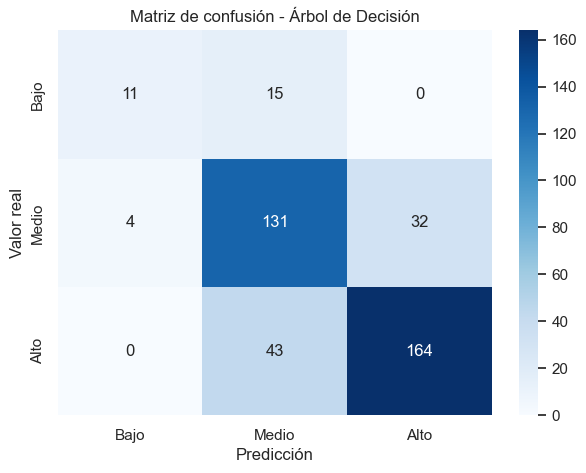

In [9]:
labels = ["Bajo", "Medio", "Alto"]

cm_arbol = confusion_matrix(y_test, y_pred_arbol, labels=labels)

plt.figure(figsize=(7,5))
sns.heatmap(
    cm_arbol,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.title("Matriz de confusión - Árbol de Decisión")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [10]:
modelo_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)

In [11]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy Random Forest:", round(accuracy_rf, 4))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_rf))

Accuracy Random Forest: 0.8725

Reporte de clasificación:
              precision    recall  f1-score   support

        Alto       0.94      0.91      0.92       207
        Bajo       0.89      0.31      0.46        26
       Medio       0.81      0.92      0.86       167

    accuracy                           0.87       400
   macro avg       0.88      0.71      0.75       400
weighted avg       0.88      0.87      0.86       400



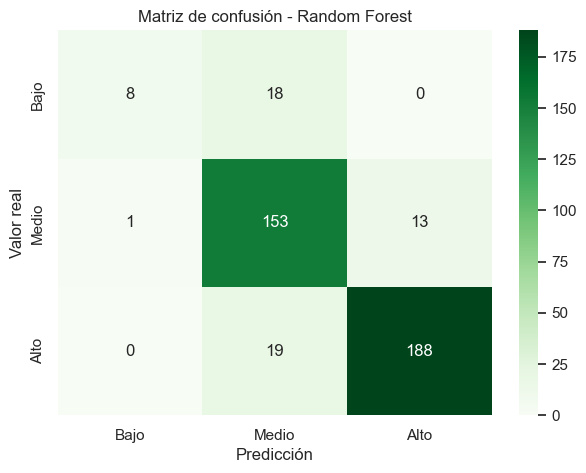

In [12]:
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=labels)

plt.figure(figsize=(7,5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=labels,
    yticklabels=labels
)
plt.title("Matriz de confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

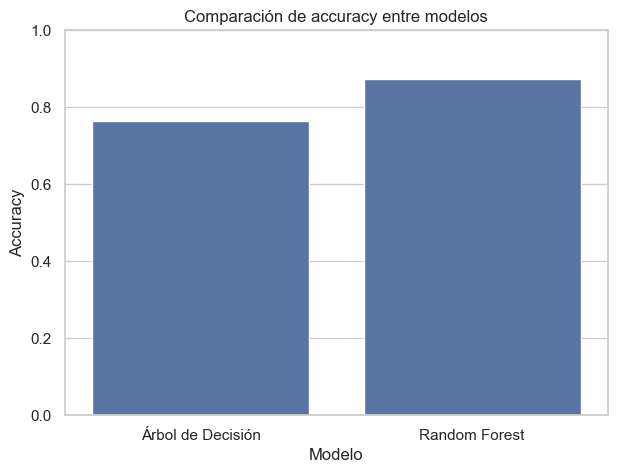

In [13]:
comparacion = pd.DataFrame({
    "Modelo": ["Árbol de Decisión", "Random Forest"],
    "Accuracy": [accuracy_arbol, accuracy_rf]
})

comparacion

plt.figure(figsize=(7,5))
sns.barplot(data=comparacion, x="Modelo", y="Accuracy")
plt.title("Comparación de accuracy entre modelos")
plt.ylim(0, 1)
plt.show()

## Comparación de modelos

El Árbol de Decisión se utilizó como modelo base por su facilidad de interpretación. Este modelo permite explicar de forma sencilla cómo ciertas variables llevan a una clasificación de riesgo.

Random Forest se utilizó como modelo final porque combina múltiples árboles de decisión, reduciendo el riesgo de sobreajuste y mejorando la capacidad predictiva.

Para este proyecto, el foco principal no es solo obtener un alto accuracy, sino detectar correctamente los casos de riesgo alto. En un escenario real de rescate, clasificar erróneamente una zona peligrosa como segura podría representar un riesgo para la operación.

In [14]:
importancias = pd.DataFrame({
    "variable": X.columns,
    "importancia": modelo_rf.feature_importances_
})

importancias = importancias.sort_values(by="importancia", ascending=False)

importancias.head(15)

,variable,importancia
8,vibracion,0.133048
17,visibilidad,0.132843
9,inclinacion,0.121374
7,gas_ppm,0.103990
12,senal_comunicacion,0.078932
6,particulas_pm25,0.071190
5,co2,0.069136
10,distancia_obstaculo,0.052887
0,temperatura,0.028038
4,sonido_db,0.026891


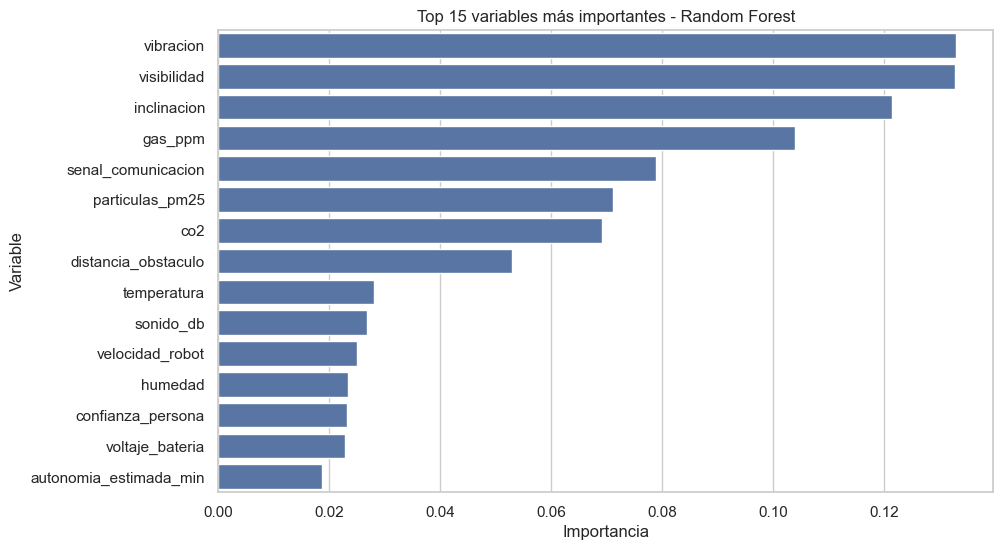

In [15]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=importancias.head(15),
    x="importancia",
    y="variable"
)
plt.title("Top 15 variables más importantes - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

## Interpretación de variables importantes

La importancia de variables permite identificar qué sensores tienen mayor influencia en la predicción del nivel de riesgo.

Se espera que variables como vibración, inclinación, concentración de gas, visibilidad, CO2, partículas y batería tengan un impacto relevante, ya que representan condiciones críticas para la navegación del robot en una zona de derrumbe.

Esta información aporta valor al negocio porque permite priorizar qué sensores son más importantes para futuras versiones del robot o del sistema de monitoreo.

In [16]:
ejemplo = X_test.iloc[[0]]

prediccion = modelo_rf.predict(ejemplo)

print("Predicción del modelo:", prediccion[0])

Predicción del modelo: Alto


In [17]:
proba = modelo_rf.predict_proba(ejemplo)

pd.DataFrame(
    proba,
    columns=modelo_rf.classes_
)

,Alto,Bajo,Medio
0,0.77,0.005,0.225


In [18]:
os.makedirs("../models", exist_ok=True)

In [19]:
joblib.dump(modelo_rf, "../models/random_forest_rescuetwin.pkl")
joblib.dump(X.columns.tolist(), "../models/model_columns.pkl")

print("Modelo guardado correctamente en ../models/random_forest_rescuetwin.pkl")
print("Columnas guardadas correctamente en ../models/model_columns.pkl")

Modelo guardado correctamente en ../models/random_forest_rescuetwin.pkl
Columnas guardadas correctamente en ../models/model_columns.pkl


In [20]:
modelo_cargado = joblib.load("../models/random_forest_rescuetwin.pkl")
columnas_cargadas = joblib.load("../models/model_columns.pkl")

print("Modelo cargado correctamente")
print("Cantidad de columnas esperadas:", len(columnas_cargadas))

Modelo cargado correctamente
Cantidad de columnas esperadas: 25


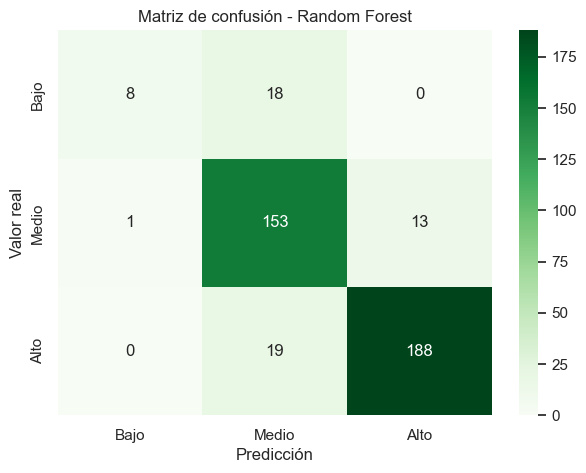

In [21]:
os.makedirs("../reports/graficos", exist_ok=True)

plt.figure(figsize=(7,5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=labels,
    yticklabels=labels
)
plt.title("Matriz de confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.savefig("../reports/graficos/matriz_confusion_random_forest.png", bbox_inches="tight")
plt.show()

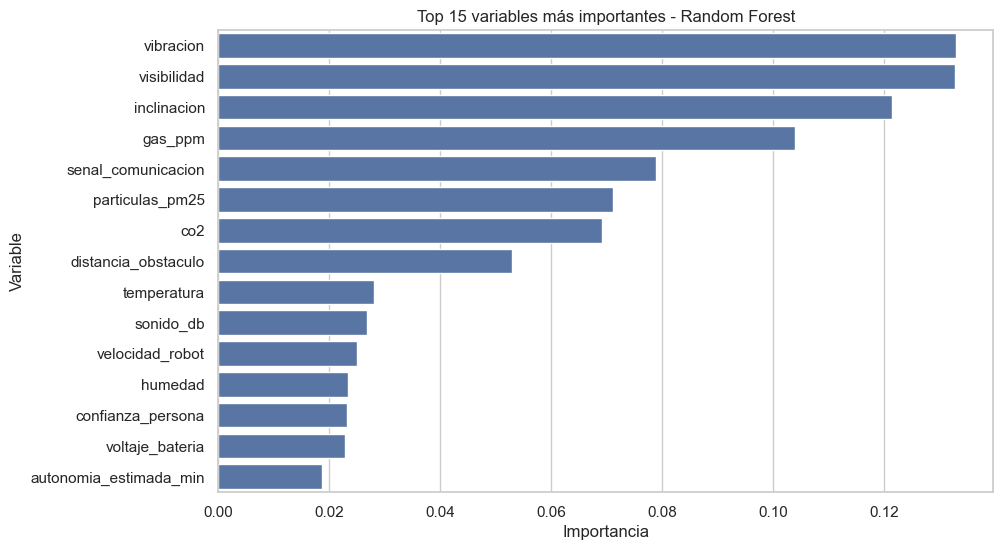

In [22]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=importancias.head(15),
    x="importancia",
    y="variable"
)
plt.title("Top 15 variables más importantes - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.savefig("../reports/graficos/importancia_variables_random_forest.png", bbox_inches="tight")
plt.show()

## Conclusión del modelado

El modelo Random Forest fue seleccionado como modelo final debido a su capacidad para clasificar el nivel de riesgo operativo a partir de múltiples variables de sensores.

El modelo permite predecir si una zona de derrumbe presenta riesgo bajo, medio o alto, y esta predicción será utilizada posteriormente en una aplicación funcional para recomendar acciones al operador del robot.

La solución aporta valor al dominio de rescate urbano porque permite tomar decisiones basadas en datos antes de exponer al personal humano a zonas potencialmente peligrosas.